In [68]:
import numpy as np
import mpmath
import matplotlib.pyplot as plt
import pygridsynth as gridsynth

from bloqade import squin, tsim
from bloqade.cirq_utils import emit_circuit
import cirq

from bloqade.pyqrack import StackMemorySimulator

In [69]:
def show_circuit(squin_kernel):
    @squin.kernel
    def _to_visualize():
        _ = squin_kernel()

    return tsim.Circuit(_to_visualize).diagram(height=400)

In [70]:
@squin.kernel
def t_gate_teleportation(psi):
    magic_state = squin.qalloc(1)
    squin.h(magic_state[0])
    squin.t(magic_state[0])

    squin.cx(psi[0], magic_state[0])

    bit = squin.measure(magic_state[0])

    if bit == 1:
        squin.s(psi[0])
    
    return psi

In [77]:
@squin.kernel
def bell_state():
    q = squin.qalloc(2)
    squin.h(q[0])
    squin.cx(q[0],q[1])
    return q

@squin.kernel
def test_t_gate_teleportation():
    bell = bell_state()
    bell = t_gate_teleportation(bell)
    squin.t_adj(bell[1])
    return bell

bell_simulator = StackMemorySimulator(min_qubits=2)
bell_task = bell_simulator.task(bell_state)
bell = bell_task.run()
rho_bell = StackMemorySimulator.reduced_density_matrix(bell)

teleport_simulator = StackMemorySimulator(min_qubits=3)
teleport_task = teleport_simulator.task(test_t_gate_teleportation)
psi = teleport_task.run()
rho_psi = StackMemorySimulator.reduced_density_matrix(psi)

print("Density matrix of bell:")
print(rho_bell)
print()
print("Density matrix of psi:")
print(rho_psi)
print()
print("Do the two states match?", np.allclose(rho_bell, rho_psi))

Density matrix of bell:
[[0.50000003-0.j 0.        +0.j 0.        +0.j 0.50000003-0.j]
 [0.        +0.j 0.        +0.j 0.        +0.j 0.        +0.j]
 [0.        +0.j 0.        +0.j 0.        +0.j 0.        +0.j]
 [0.50000003+0.j 0.        +0.j 0.        +0.j 0.50000003+0.j]]

Density matrix of psi:
[[0.50000002+0.j         0.        +0.j         0.        +0.j
  0.49999997+0.00000006j]
 [0.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j        ]
 [0.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j        ]
 [0.49999997-0.00000006j 0.        +0.j         0.        +0.j
  0.49999993+0.j        ]]

Do the two states match? True


In [78]:
import json
import os

gridsynth_results = {}

with open("gridsynth_results.json", "r") as f:
    loaded_data = json.load(f)
    for k, v in loaded_data.items():
        gridsynth_results[eval(k)] = v

print("Loaded Gridsynth results:")
for key, value in gridsynth_results.items():
    print(f"n={key[0]}, eps={key[1]}: {value}")

Loaded Gridsynth results:
n=3, eps=0.01: HTHTSHTHTSHTSHTHTHTSHTSHTHTHTSHTSHTSHTHTSHTHTSHSSW
n=3, eps=0.001: HTSHTSHTSHTHTHTHTHTHTHTSHTHTHTSHTSHTHTSHTSHTHTSHTSHTSHTSHTHTSHTSHTSHTHTHTHTHTSHTHTHTHXSSWWWWW
n=3, eps=0.0001: HTHTHTSHTSHTHTHTHTHTSHTSHTHTHTHTHTSHTHTHTHTSHTSHTHTHTSHTHTSHTSHTSHTSHTHTHTSHTHTSHTSHTSHTSHTHTHTHTSHTSHTHTSHTSW
n=3, eps=0.00001: HTSHTHTHTSHTSHTSHTSHTHTSHTSHTSHTHTSHTHTSHTHTHTSHTSHTSHTHTSHTHTSHTHTHTHTHTHTHTSHTHTSHTHTHTSHTSHTHTSHTSHTSHTSHTHTHTHTSHTSHTSHTHTHSSS
n=4, eps=0.01: HTHTHTSHTHTSHTSHTSHTHTSHTSHTHTSHTHTHTSHTSHTSHTSHTHTSHXSSWWWW
n=4, eps=0.001: THTSHTSHTHTSHTSHTSHTSHTSHTHTHTSHTSHTHTSHTHTSHTHTHTHTSHTHTHTSHTHTSHTHTSHTSHTHTHTSHTSHTHXSSS
n=4, eps=0.0001: SHTSHTHTSHTHTHTHTHTSHTHTHTSHTSHTHTHTSHTSHTSHTHTSHTSHTHTHTHTSHTSHTSHTSHTHTSHTSHTSHTSHTHTSHTSHTHTSHTHTSHTSHTHTSWW
n=4, eps=0.00001: SHTHTHTHTHTSHTHTSHTHTSHTSHTHTHTSHTHTHTSHTHTHTHTHTHTHTSHTSHTHTHTSHTHTHTSHTHTSHTSHTHTHTHTSHTSHTHTHTSHTHTHTHTHTSHTSHTHTSHTHTSHTXSWWW
n=5, eps=0.01: SHTSHTHTHTSHTHTHTHTHTSHTHTHTSHTSHTHTSHTHTHTSHT

In [79]:
def string_to_unitary(gate_string):
    @squin.kernel
    def circ():
        q = squin.qalloc(1)
        for char in gate_string:
            if char == "H":
                squin.h(q[0])
            elif char == "S":
                squin.s(q[0])
            elif char == "T":
                squin.t(q[0])
            elif char == "X":
                squin.x(q[0])
            elif char == "Y":
                squin.y(q[0])
            elif char == "Z":
                squin.z(q[0])
            # We ignore "W" since it is just a global phase and our distance metric is invariant to it.
        return q
        
    c = emit_circuit(circ, ignore_returns=True)
    # Handle empty circuits safely
    if not c.all_qubits():
        return np.eye(2, dtype=complex)
    return cirq.unitary(c)


def rz(theta):
    return np.array([[np.exp(-1j * theta / 2), 0],
                     [0, np.exp(1j * theta / 2)]], dtype=complex)

def distance(U, V):
    tr = np.trace(U.conj().T @ V)
    val = 1 - np.abs(tr)/2
    if val < 0: val = 0
    return np.sqrt(val)

In [ ]:
mpmath.mp.dps = 128

epsilon = mpmath.mpf("1e-4")
exact_gates = {0: "Z", 1: "S", 2: "T"}

results = []
for n in range(6):
    theta_val = np.pi / (2**n)
    U_target = rz(theta_val)

    if n in exact_gates:
        gates = exact_gates[n]
    else:
        key = (n, str(epsilon))
        if key not in gridsynth_results:
            raise KeyError(f"Missing saved Gridsynth result for {key}")
        gates = gridsynth_results[key]

    # Evaluate distance using the logical unitary of the gate string
    U_approx = string_to_unitary(gates)
    dist = distance(U_target, U_approx)

    t_count = gates.count("T")
    results.append({
        "n": n,
        "gates": gates,
        "length": len(gates),
        "t_count": t_count,
        "distance": dist
    })
    print(f"n={n}: target Rz(pi/{2**n})")
    print(f"  Distance: {dist:.2e}")
    print(f"  T-count:  {t_count}")
    print(f"  Length:   {len(gates)}")
    print(f"  Sequence: {gates}\n")


n=0: target Rz(pi/1)
  Distance: 0.00e+00
  T-count:  0
  Length:   1
  Sequence: Z

n=1: target Rz(pi/2)
  Distance: 0.00e+00
  T-count:  0
  Length:   1
  Sequence: S



ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 4 is different from 2)

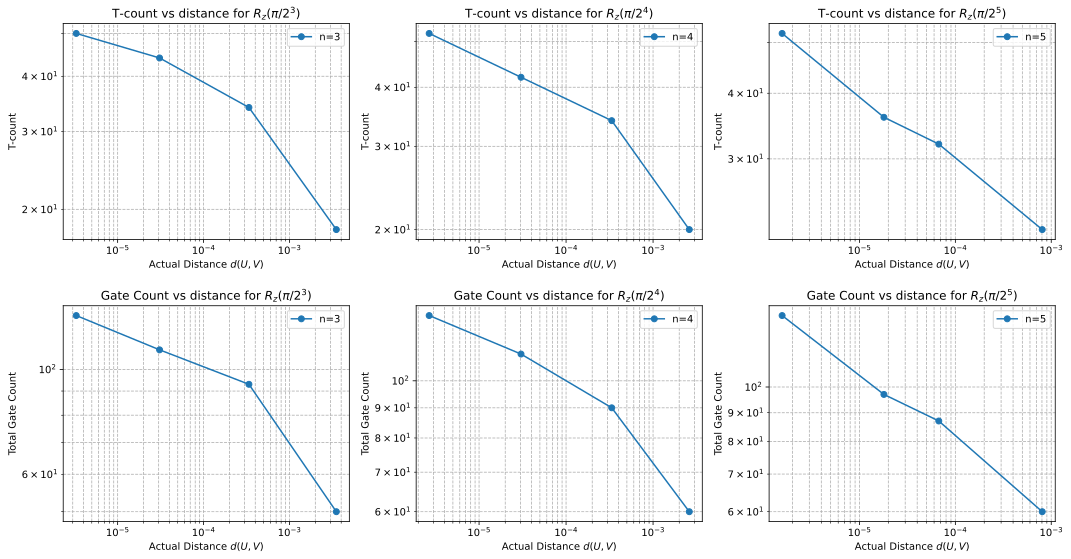

In [ ]:
# PyGridSynth Analysis: T-count and Depth vs Teleportation-Aware Distance
n_values = [3, 4, 5]
metrics = ["t_count", "depth"]
fig, axes = plt.subplots(len(metrics), len(n_values), figsize=(5 * len(n_values), 4 * len(metrics)))

for j, n_val in enumerate(n_values):
    theta_val = np.pi / (2**n_val)
    U_target = rz(theta_val)

    # Sweep over the saved epsilons and record the actual approximation distances
    epsilons = [mpmath.mpf(f"1e-{k}") for k in range(2, 6)]
    distances = []
    tcounts = []
    depths = []

    for eps in epsilons:
        key = (n_val, str(eps))
        if key not in gridsynth_results:
            raise KeyError(f"Missing saved Gridsynth result for {key}")

        gates = gridsynth_results[key]

        # Distance in the teleportation model: T is interpreted via its injection-aware logical action.
        U_impl = string_to_unitary_injection(gates)
        dist = distance(U_target, U_impl)

        distances.append(dist)
        tcounts.append(gates.count("T"))
        depths.append(len(gates))

    # T-count plot
    ax_t = axes[0, j]
    ax_t.plot(distances, tcounts, marker="o", label=f"n={n_val}")
    ax_t.set_xscale("log")
    ax_t.set_yscale("log")
    ax_t.set_xlabel("Actual Distance $d(U, V)$")
    ax_t.set_ylabel("T-count")
    ax_t.set_title(f"T-count vs distance for $R_z(\\pi/2^{{{n_val}}})$")
    ax_t.grid(True, which="both", ls="--")
    ax_t.legend()

    # Depth plot
    ax_d = axes[1, j]
    ax_d.plot(distances, depths, marker="o", label=f"n={n_val}")
    ax_d.set_xscale("log")
    ax_d.set_yscale("log")
    ax_d.set_xlabel("Actual Distance $d(U, V)$")
    ax_d.set_ylabel("Total Gate Count")
    ax_d.set_title(f"Gate Count vs distance for $R_z(\\pi/2^{{{n_val}}})$")
    ax_d.grid(True, which="both", ls="--")
    ax_d.legend()

plt.tight_layout()
plt.show()

In [ ]:
#import mpmath
#import pygridsynth as gridsynth
#from qiskit import QuantumCircuit
#from qiskit.visualization import visualize_transition
#
#n_val = 4
#theta_mp = mpmath.mpf(mpmath.pi) / (2**n_val)
#eps = mpmath.mpf("1e-5")
#
## Synthesize with pygridsynth
#gates_str = gridsynth.gridsynth_gates(theta=theta_mp, epsilon=eps)
#
#qc = QuantumCircuit(1)
#for char in gates_str:
#    if char == "H":
#        qc.h(0)
#    elif char == "S":
#        qc.s(0)
#    elif char == "T":
#        qc.t(0)
#    elif char == "X":
#        qc.x(0)
#    elif char == "Y":
#        qc.y(0)
#    elif char == "Z":
#        qc.z(0)
#
#visualize_transition(
#    circuit=qc, 
#    trace=True,                           # Displays tracing vectors showing the history of 10 past vectors
#    saveas="bloch_rotation_sequence.gif", # Saves the animation as a video to your filesystem
#    fpg=15,                               # Frames per gate for smoother animation (5-30 is recommended for Jupyter)
#    spg=0.5                                 # Number of seconds the animation of individual gate transitions should take
#)

In [ ]:
from synthesis_part3 import evaluate_synthesis_costs

mpmath.mp.dps = 128
epsilon = mpmath.mpf("1e-4")

exact_gates = {0: "Z", 1: "S", 2: "T"}

results = []
for n in range(6):
    theta_val = np.pi / (2**n)
    theta_mp = mpmath.mpf(mpmath.pi) / (2**n)
    
    if n in exact_gates:
        gates = exact_gates[n]
    else:
        if n == 2:
            gates = "T"  # We know T is exact for n=2
        else:
        # Synthesize with pygridsynth
            gates = gridsynth.gridsynth_gates(theta=theta_mp, epsilon=epsilon)
    #print(gates)
    ## Evaluate distance
    #U_approx = string_to_unitary_injection(gates)
    #if 'T' in gates:
    #    U_target = rz_two_qubits(theta_val)
    #else:
    #    U_target = rz(theta_val)
    #dist = distance(U_target, U_approx)
    
    costs = evaluate_synthesis_costs(gates)

    print(f"Sequence: {gates}")
    #print(f"Approximation Distance: {dist:.6f}")
    print(f"Hardware Costs with T-Injection:")
    for k, v in costs.items():
        print(f"  - {k}: {v}")
        
    print(f"\nNotice now a 1-qubit R_z(pi/{2**n}) requires:")
    print(f"  - {costs['2_qubit_gate_count']} CNOTs (2-qubit gates)")
    print(f"  - {costs['ancilla_count']} Extra physical qubits")
    print(f"  - {costs['feed_forward']} Feed-forward classical measurements")
    print(f"  - {costs['repeated_trials']} Expected trials if feed-forward is unavailable")
    print()
    print()


Sequence: Z
Hardware Costs with T-Injection:
  - logical_gates: 1
  - ancilla_count: 0
  - 2_qubit_gate_count: 0
  - feed_forward: 0
  - circuit_depth: 1
  - repeated_trials: 1

Notice now a 1-qubit R_z(pi/1) requires:
  - 0 CNOTs (2-qubit gates)
  - 0 Extra physical qubits
  - 0 Feed-forward classical measurements
  - 1 Expected trials if feed-forward is unavailable


Sequence: S
Hardware Costs with T-Injection:
  - logical_gates: 1
  - ancilla_count: 0
  - 2_qubit_gate_count: 0
  - feed_forward: 0
  - circuit_depth: 1
  - repeated_trials: 1

Notice now a 1-qubit R_z(pi/2) requires:
  - 0 CNOTs (2-qubit gates)
  - 0 Extra physical qubits
  - 0 Feed-forward classical measurements
  - 1 Expected trials if feed-forward is unavailable


Sequence: T
Hardware Costs with T-Injection:
  - logical_gates: 1
  - ancilla_count: 1
  - 2_qubit_gate_count: 1
  - feed_forward: 1
  - circuit_depth: 3
  - repeated_trials: 2

Notice now a 1-qubit R_z(pi/4) requires:
  - 1 CNOTs (2-qubit gates)
  - 1 Ext